# Modelo Preditivo de Risco de Defasagem — Passos Mágicos
**Datathon PosTech · Fase 5**

Este notebook constrói um modelo preditivo (early-warning) que estima a
**probabilidade de um aluno entrar em risco de defasagem** — isto é, de a sua
defasagem **piorar no ano seguinte** — a partir dos seus indicadores atuais
(IAN, IDA, IEG, IAA, IPS, IPP, IPV, INDE) e dados demográficos.

Etapas: **feature engineering → separação treino/teste → modelagem → avaliação**.

> **Por que um alvo longitudinal?** O enunciado pede identificar o risco *"antes
> de queda no desempenho ou aumento da defasagem"*. Como a defasagem *atual* é
> quase determinística (defasagem = fase − fase ideal para a idade), prever o
> **nível atual** apenas reproduziria essa fórmula. Prevemos, então, a
> **mudança futura** (piora), tornando o modelo genuinamente preditivo e útil
> para intervenção precoce.

## 1. Configuração e carga dos dados

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score)
import joblib

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(BASE / "data" / "processed" / "pede_unificado.csv")
print("Base unificada:", df.shape, "| alunos únicos:", df.RA.nunique())
df.head()

Base unificada: (3030, 24) | alunos únicos: 1661


,RA,ano,fase,idade,genero,ano_ingresso,inde,pedra,iaa,ieg,...,ian,nota_mat,nota_port,nota_ing,defasagem,atingiu_pv,indicado_bolsa,em_risco_defasagem,categoria_defasagem,anos_na_pm
0,RA-1,2022,7,19.0,Feminino,2016,5.783,Quartzo,8.3,4.1,...,5.0,2.7,3.5,6.0,-1,0.0,1.0,0,Defasagem leve,6.0
1,RA-1,2023,8,NaN,Feminino,2016,NaN,NaN,NaN,NaN,...,10.0,NaN,NaN,NaN,0,NaN,NaN,0,Adequado,7.0
2,RA-1,2024,8,21.0,Feminino,2021,NaN,NaN,NaN,0.0,...,10.0,NaN,NaN,NaN,0,NaN,NaN,0,Adequado,3.0
3,RA-10,2022,7,18.0,Feminino,2021,5.784,Quartzo,8.3,5.2,...,5.0,3.3,2.6,6.4,-1,0.0,0.0,0,Defasagem leve,1.0
4,RA-100,2022,4,13.0,Feminino,2019,7.618,Ametista,8.8,7.8,...,10.0,7.0,7.8,8.1,1,0.0,0.0,0,Adiantado,3.0


## 2. Feature engineering

Construímos o **alvo longitudinal** usando a chave `RA` para ligar o mesmo aluno
entre anos: `risco_piora = 1` se a defasagem do ano seguinte for **pior**
(mais negativa) que a atual.

In [2]:
df = df.sort_values(["RA", "ano"]).copy()
df["defasagem_prox"] = df.groupby("RA")["defasagem"].shift(-1)
base = df[df["defasagem_prox"].notna()].copy()
base["risco_piora"] = (base["defasagem_prox"] < base["defasagem"]).astype(int)

NUM_FEATS = ["inde","ida","ieg","iaa","ips","ipp","ipv","ian","idade","fase","defasagem","anos_na_pm"]
CAT_FEATS = ["genero"]
FEATURES = NUM_FEATS + CAT_FEATS
TARGET = "risco_piora"

X, y = base[FEATURES].copy(), base[TARGET].copy()
print(f"Universo modelável: {len(X)} registros aluno-ano")
print(f"Positivos (vão piorar): {y.sum()} ({y.mean()*100:.1f}%)")
y.value_counts(normalize=True).rename({0:'Estável/Melhora',1:'Piora'})

Universo modelável: 1369 registros aluno-ano
Positivos (vão piorar): 236 (17.2%)


risco_piora
Estável/Melhora    0.827611
Piora              0.172389
Name: proportion, dtype: float64

Distribuição do alvo e completude das features:

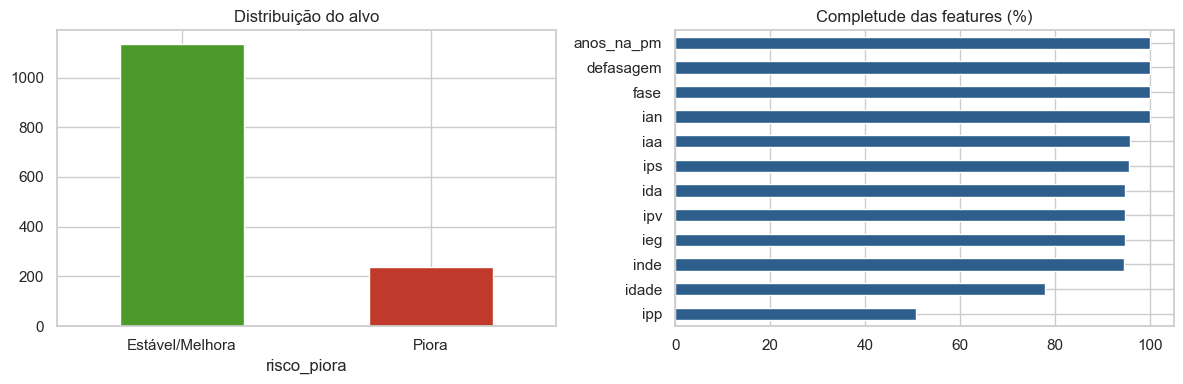

In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
y.map({0:'Estável/Melhora',1:'Piora'}).value_counts().plot(kind='bar', ax=ax[0], color=['#4C9A2A','#C0392B'])
ax[0].set_title('Distribuição do alvo'); ax[0].tick_params(axis='x', rotation=0)
(X[NUM_FEATS].notna().mean()*100).sort_values().plot(kind='barh', ax=ax[1], color='#2E5E8C')
ax[1].set_title('Completude das features (%)')
plt.tight_layout(); plt.show()

## 3. Separação treino/teste

Divisão estratificada (75% treino / 25% teste) para preservar a proporção de
casos de risco.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print("Treino:", len(X_tr), "| Teste:", len(X_te))

Treino: 1026 | Teste: 343


### Pré-processamento

- **Numéricas:** imputação pela mediana + padronização.
- **Categóricas:** imputação pela moda + one-hot encoding.

A imputação é essencial porque o IPP não existe em 2022 e há ausências pontuais.

In [5]:
num = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat = Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))])
pre = ColumnTransformer([("num", num, NUM_FEATS), ("cat", cat, CAT_FEATS)])

## 4. Modelagem

Comparamos três algoritmos com validação cruzada estratificada (5 folds), todos
com balanceamento de classes por serem os casos de risco a minoria.

In [6]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=8,
                                            class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300,
                                                        class_weight="balanced", random_state=42),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados, pipes = {}, {}
for nome, clf in modelos.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    auc_cv = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc").mean()
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:,1]
    resultados[nome] = {"AUC (CV)": auc_cv, "AUC (teste)": roc_auc_score(y_te, proba),
                        "PR-AUC (teste)": average_precision_score(y_te, proba)}
    pipes[nome] = pipe
pd.DataFrame(resultados).T.round(3).sort_values("AUC (teste)", ascending=False)

,AUC (CV),AUC (teste),PR-AUC (teste)
Random Forest,0.877,0.876,0.582
Gradient Boosting,0.879,0.857,0.580
Regressão Logística,0.840,0.853,0.559


## 5. Avaliação do melhor modelo

In [7]:
melhor_nome = max(resultados, key=lambda k: resultados[k]["AUC (teste)"])
melhor = pipes[melhor_nome]
print("Melhor modelo:", melhor_nome)
proba = melhor.predict_proba(X_te)[:,1]

# Limiar que maximiza F1 (sob desbalanceamento)
grid = np.linspace(0.1, 0.9, 81)
limiar = float(grid[np.argmax([f1_score(y_te, (proba>=t).astype(int), zero_division=0) for t in grid])])
pred = (proba >= limiar).astype(int)
print(f"Limiar ótimo (máx F1) = {limiar:.2f}\n")
print(classification_report(y_te, pred, target_names=["Sem risco","Em risco"]))

Melhor modelo: Random Forest


Limiar ótimo (máx F1) = 0.56

              precision    recall  f1-score   support

   Sem risco       0.94      0.85      0.89       284
    Em risco       0.51      0.73      0.60        59

    accuracy                           0.83       343
   macro avg       0.72      0.79      0.75       343
weighted avg       0.86      0.83      0.84       343



Matriz de confusão e curva ROC:

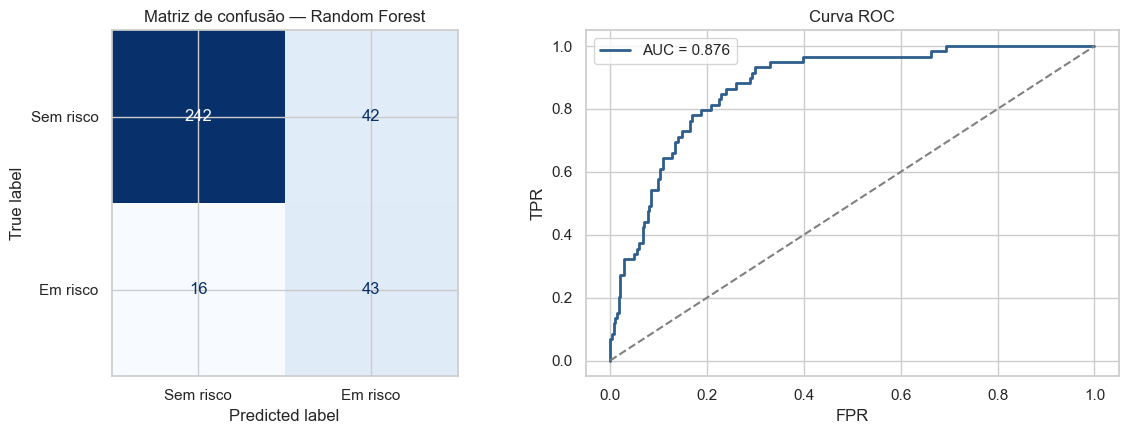

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=["Sem risco","Em risco"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title(f"Matriz de confusão — {melhor_nome}")
fpr, tpr, _ = roc_curve(y_te, proba)
ax[1].plot(fpr, tpr, color="#2E5E8C", lw=2, label=f"AUC = {resultados[melhor_nome]['AUC (teste)']:.3f}")
ax[1].plot([0,1],[0,1],'--', color='gray'); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
ax[1].set_title("Curva ROC"); ax[1].legend()
plt.tight_layout(); plt.show()

### Importância das variáveis (permutação)

Mede a queda no AUC ao embaralhar cada variável — quanto maior, mais o modelo
depende dela.

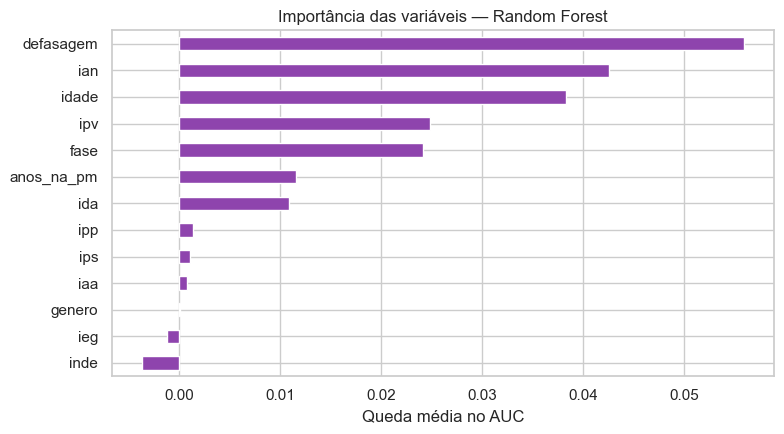

defasagem     0.0559
ian           0.0425
idade         0.0383
ipv           0.0249
fase          0.0241
anos_na_pm    0.0115
ida           0.0109
ipp           0.0014
ips           0.0010
iaa           0.0008
genero        0.0000
ieg          -0.0013
inde         -0.0037
dtype: float64

In [9]:
perm = permutation_importance(melhor, X_te, y_te, scoring="roc_auc", n_repeats=10, random_state=42)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8,4.5))
imp.plot(kind="barh", ax=ax, color="#8E44AD")
ax.set_title(f"Importância das variáveis — {melhor_nome}"); ax.set_xlabel("Queda média no AUC")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)

**Leitura de negócio:** além da defasagem atual e da idade/fase (que situam o
aluno no ciclo), o **IPV (ponto de virada)** e o **IDA (aprendizagem)** são os
indicadores pedagógicos que mais antecipam a piora — reforçando que engajar o
aluno rumo ao ponto de virada tem efeito protetor.

## 6. Persistência do modelo

In [10]:
import json
MODELS = BASE / "models"; MODELS.mkdir(exist_ok=True)
joblib.dump(melhor, MODELS / "modelo_risco.joblib")
meta = {"melhor_modelo": melhor_nome, "features_numericas": NUM_FEATS,
        "features_categoricas": CAT_FEATS, "target": TARGET,
        "definicao_target": "piora da defasagem no ano seguinte",
        "limiar_padrao": round(limiar,2), "metricas": resultados,
        "prevalencia_risco": float(y.mean())}
(MODELS / "modelo_meta.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print("Modelo e metadados salvos em", MODELS)

Modelo e metadados salvos em C:\Users\Logcomex\Desktop\Pos Tech - Copia\Fase 5\passos-magicos-datathon\models


## 7. Exemplo de uso — probabilidade individual de risco

O objeto salvo é um *pipeline* completo (pré-processamento + modelo), pronto para
receber novos alunos e devolver a probabilidade de risco — é exatamente o que a
aplicação Streamlit consome.

In [11]:
exemplo = pd.DataFrame([{
    "inde": 6.2, "ida": 5.0, "ieg": 5.5, "iaa": 7.0, "ips": 5.0, "ipp": 5.5,
    "ipv": 4.5, "ian": 5.0, "idade": 14, "fase": 3, "defasagem": -1,
    "anos_na_pm": 2, "genero": "Feminino"}])
p = melhor.predict_proba(exemplo)[0,1]
print(f"Probabilidade de piora da defasagem no próximo ano: {p*100:.1f}%")
print("Classificação:", "EM RISCO" if p >= limiar else "sem risco imediato")

Probabilidade de piora da defasagem no próximo ano: 47.2%
Classificação: sem risco imediato
